# Week 1 — Python & NumPy in 90 minutes

**Course:** Data Science for Electron Microscopy  
**Author:** Prof. Dr. Philipp Pelz, FAU Erlangen-Nürnberg  

---

**Learning goals** (tick these off as you go):
- [ ] Understand Python variables, lists, and functions
- [ ] Create and manipulate NumPy arrays
- [ ] Use array indexing, slicing, and broadcasting
- [ ] Display an image and a line profile with matplotlib
- [ ] Crop and min-max-normalise a synthetic STEM-like image

**Estimated time:** 60–90 minutes for a complete beginner; 30–45 minutes if you already know Python.

**How to run:** Click *Runtime → Run all* (Colab) or *Kernel → Restart & Run All* (local Jupyter). Every cell must run without errors before you submit the miniproject proposal in Week 6.

> **Note:** All data in this notebook is synthetically generated — no downloads required.

In [1]:
# ── Cell 1: install / import ──────────────────────────────────────────────────
# NumPy and matplotlib are pre-installed in Colab and standard Anaconda.
# If running on a minimal environment, uncomment the next line.
# !pip install numpy matplotlib --quiet

import numpy as np
import matplotlib.pyplot as plt
import sys

print(f"Python  {sys.version.split()[0]}")
print(f"NumPy   {np.__version__}")
import matplotlib
print(f"matplotlib {matplotlib.__version__}")

Python  3.12.10
NumPy   1.26.4
matplotlib 3.10.3


---
## Part 1 — Variables, types, and lists

Python infers types automatically. The most common numeric types you will encounter in EM data pipelines are `int` and `float`.

In [2]:
# ── Cell 2: variables ─────────────────────────────────────────────────────────
n_pixels      = 512           # image dimension (int)
pixel_size_nm = 0.05          # calibration: nm per pixel (float)
modality      = "HAADF-STEM" # acquisition mode (str)
is_calibrated = True          # flag (bool)

print(f"Image size : {n_pixels} × {n_pixels} px")
print(f"FOV        : {n_pixels * pixel_size_nm:.1f} nm")
print(f"Modality   : {modality}")
print(f"Calibrated : {is_calibrated}")
print(f"Type of pixel_size_nm: {type(pixel_size_nm)}")

Image size : 512 × 512 px
FOV        : 25.6 nm
Modality   : HAADF-STEM
Calibrated : True
Type of pixel_size_nm: <class 'float'>


In [3]:
# ── Cell 3: lists ─────────────────────────────────────────────────────────────
# A list of beam energies used in a multi-voltage experiment
voltages_kV = [60, 80, 100, 200, 300]

print(f"Voltages: {voltages_kV}")
print(f"First   : {voltages_kV[0]} kV   ← index 0 (Python starts at 0!)")
print(f"Last    : {voltages_kV[-1]} kV  ← negative index counts from end")
print(f"Slice [1:3]: {voltages_kV[1:3]}  ← stop index is EXCLUDED")

# Append a new voltage
voltages_kV.append(30)
print(f"After append: {voltages_kV}")

Voltages: [60, 80, 100, 200, 300]
First   : 60 kV   ← index 0 (Python starts at 0!)
Last    : 300 kV  ← negative index counts from end
Slice [1:3]: [80, 100]  ← stop index is EXCLUDED
After append: [60, 80, 100, 200, 300, 30]


---
## Part 2 — Functions

A function packages a reusable operation and gives it a name. Always add a docstring.

In [4]:
# ── Cell 4: defining and calling functions ────────────────────────────────────

def normalize(image):
    """
    Min-max normalise an array to the range [0, 1].

    Parameters
    ----------
    image : np.ndarray
        Input array of any shape and numeric dtype.

    Returns
    -------
    np.ndarray
        Array with same shape, values in [0, 1].

    Note: a constant image (max==min) yields NaN; guard with
    ``if hi==lo: return np.zeros_like(...)`` in real pipelines.
    """
    img_min = image.min()
    img_max = image.max()
    return (image - img_min) / (img_max - img_min)


# Quick test with a small array
test = np.array([0.0, 50.0, 200.0, 1000.0])
print(f"Input  : {test}")
print(f"Output : {normalize(test)}")
print(f"Min should be 0.0: {normalize(test).min()}")
print(f"Max should be 1.0: {normalize(test).max()}")

Input  : [   0.   50.  200. 1000.]
Output : [0.   0.05 0.2  1.  ]
Min should be 0.0: 0.0
Max should be 1.0: 1.0


---
## Part 3 — NumPy arrays: creation, shape, dtype

NumPy arrays are the core data structure for everything in this course. Every EM dataset — image, spectrum, 4D-STEM cube — is an ndarray.

In [5]:
# ── Cell 5: array creation ────────────────────────────────────────────────────

# From a list
a = np.array([1.0, 2.0, 4.0, 8.0])
print(f"1-D array : {a}")
print(f"shape     : {a.shape}   (1 axis, 4 elements)")
print(f"dtype     : {a.dtype}")

# 2-D array
M = np.array([[1, 2, 3],
              [4, 5, 6]])
print(f"\n2-D array shape: {M.shape}  (2 rows, 3 columns)")

# Common initialisers
zeros = np.zeros((4, 4), dtype=np.float32)
ones  = np.ones((3, 3))
ramp  = np.arange(0, 1.0, 0.1)           # 0.0, 0.1, … 0.9
q     = np.linspace(0, np.pi, 128)       # 128 points from 0 to π

print(f"\nzeros shape : {zeros.shape}, dtype {zeros.dtype}")
print(f"ramp        : {ramp}")

1-D array : [1. 2. 4. 8.]
shape     : (4,)   (1 axis, 4 elements)
dtype     : float64

2-D array shape: (2, 3)  (2 rows, 3 columns)

zeros shape : (4, 4), dtype float32
ramp        : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


In [6]:
# ── Cell 6: dtype and memory footprint ────────────────────────────────────────
# A 4D-STEM scan: 256×256 probe positions, 128×128 detector pixels

shape_4dstem = (256, 256, 128, 128)

bytes_f32 = np.prod(shape_4dstem) * np.dtype(np.float32).itemsize
bytes_f64 = np.prod(shape_4dstem) * np.dtype(np.float64).itemsize

print(f"4D-STEM shape : {shape_4dstem}")
print(f"Total elements: {np.prod(shape_4dstem):,}")
print(f"Memory float32: {bytes_f32 / 1e9:.2f} GB")
print(f"Memory float64: {bytes_f64 / 1e9:.2f} GB  (2× larger — avoid on a laptop!)")

4D-STEM shape : (256, 256, 128, 128)
Total elements: 1,073,741,824
Memory float32: 4.29 GB
Memory float64: 8.59 GB  (2× larger — avoid on a laptop!)


---
## Part 4 — Indexing and slicing

All EM operations — cropping an ROI, extracting a line profile, selecting a single diffraction pattern — use array indexing.

In [7]:
# ── Cell 7: indexing a 2-D array ──────────────────────────────────────────────
np.random.seed(0)
img = np.random.randint(0, 256, size=(8, 8), dtype=np.uint8)
print("8×8 test image:")
print(img)
print()

print(f"Top-left pixel   img[0, 0]    = {img[0, 0]}")
print(f"Bottom-right     img[-1, -1]  = {img[-1, -1]}")
print(f"First row        img[0, :]    = {img[0, :]}")
print(f"Last column      img[:, -1]   = {img[:, -1]}")

# Crop a 4×4 ROI from the centre
roi = img[2:6, 2:6]
print(f"\n4×4 ROI from centre, shape={roi.shape}:")
print(roi)

8×8 test image:
[[172  10 127 140  47 170 196 151]
 [117 166  22 183 192 204  33 216]
 [ 67 179  78 154 251  82 162 219]
 [195 118 125 139 103 125 229 216]
 [  9 164 116 108 211 222 161 159]
 [ 21  81  89 165 242 214 102  98]
 [ 36 183   5 112  87  58  43  76]
 [ 70  60  75 228 216 189 132  14]]

Top-left pixel   img[0, 0]    = 172
Bottom-right     img[-1, -1]  = 14
First row        img[0, :]    = [172  10 127 140  47 170 196 151]
Last column      img[:, -1]   = [151 216 219 216 159  98  76  14]

4×4 ROI from centre, shape=(4, 4):
[[ 78 154 251  82]
 [125 139 103 125]
 [116 108 211 222]
 [ 89 165 242 214]]


In [8]:
# ── Cell 8: vectorised arithmetic (no for-loops!) ─────────────────────────────
# Simulate a 512×512 HAADF image: ~200 electron counts/pixel background
np.random.seed(42)
signal = np.full((512, 512), fill_value=200.0, dtype=np.float32)
noise  = np.random.randn(512, 512).astype(np.float32) * 15.0

# Dark-field background subtraction — vectorised, no loop
dark_offset = 5.0
corrected = signal + noise - dark_offset    # element-wise, instant

print(f"corrected shape : {corrected.shape}")
print(f"mean            : {corrected.mean():.1f}  (expected ~195)")
print(f"std             : {corrected.std():.1f}   (expected ~15)")

# Compare speed: vectorised vs loop (for illustration)
import time

t0 = time.time()
_ = signal + noise - dark_offset
t_vec = time.time() - t0

t0 = time.time()
out = np.empty_like(signal)
for i in range(signal.shape[0]):
    for j in range(signal.shape[1]):
        out[i, j] = signal[i, j] + noise[i, j] - dark_offset
t_loop = time.time() - t0

print(f"\nVectorised: {t_vec*1000:.2f} ms")
print(f"For-loop  : {t_loop*1000:.0f} ms  (~{int(t_loop/max(t_vec,1e-9))}× slower)")

corrected shape : (512, 512)
mean            : 195.0  (expected ~195)
std             : 15.0   (expected ~15)



Vectorised: 0.74 ms
For-loop  : 491 ms  (~664× slower)


---
## Part 5 — Broadcasting

Broadcasting lets you apply operations between arrays of different (but compatible) shapes without writing loops or explicitly tiling arrays.

base shape       : (64, 64)
stripe_noise shape: (64, 1)
row_mean shape   : (64, 1)
row_corrected shape: (64, 64)


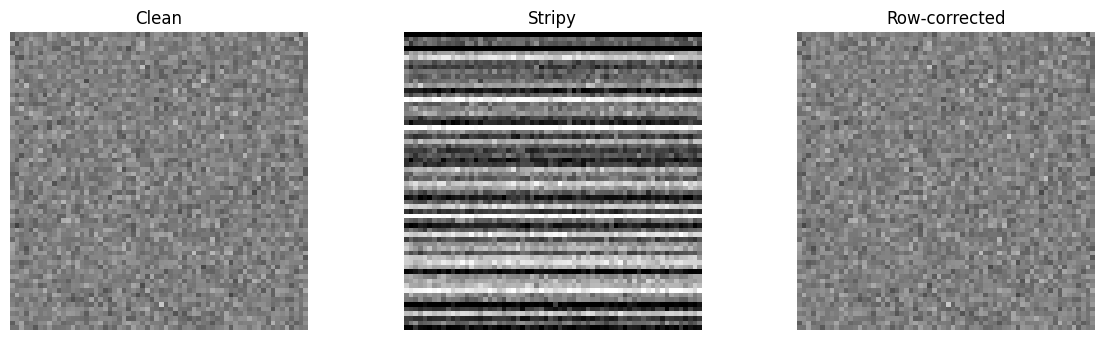

In [9]:
# ── Cell 9: broadcasting ──────────────────────────────────────────────────────
# Horizontal stripe correction: subtract the mean of each row
# (common artefact removal step in HAADF images)

np.random.seed(7)
base    = np.random.poisson(lam=200, size=(64, 64)).astype(float)

# Add artificial horizontal stripes (row-correlated noise)
stripe_noise = np.random.randn(64, 1) * 50   # shape (64, 1)
stripy = base + stripe_noise                  # broadcasts: (64,64) + (64,1) → (64,64)

# Correct by subtracting row mean
row_mean     = stripy.mean(axis=1, keepdims=True)   # shape (64, 1)
row_corrected = stripy - row_mean                    # shape (64, 64)

print(f"base shape       : {base.shape}")
print(f"stripe_noise shape: {stripe_noise.shape}")
print(f"row_mean shape   : {row_mean.shape}")
print(f"row_corrected shape: {row_corrected.shape}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
kw = dict(cmap='gray', vmin=100, vmax=300)
axes[0].imshow(base,          **kw); axes[0].set_title('Clean')
axes[1].imshow(stripy,        **kw); axes[1].set_title('Stripy')
axes[2].imshow(row_corrected + base.mean(), **kw); axes[2].set_title('Row-corrected')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## Part 6 — Matplotlib: images and line profiles

Every quantitative EM analysis starts with looking at the data.

In [10]:
# ── Cell 10: synthetic STEM image with crystalline columns ────────────────────
np.random.seed(42)

N = 256                             # image size in pixels
spacing = 20                        # lattice spacing in pixels
col_half = 2                        # half-width of each atomic column

base_counts = np.zeros((N, N), dtype=np.float64)

# Place bright columns on a square lattice
for r in range(spacing // 2, N, spacing):
    for c in range(spacing // 2, N, spacing):
        r0, r1 = max(r - col_half, 0), min(r + col_half + 1, N)
        c0, c1 = max(c - col_half, 0), min(c + col_half + 1, N)
        base_counts[r0:r1, c0:c1] = 800.0

# Background intensity
base_counts += 50.0

# Poisson noise (realistic detector model)
stem_image = np.random.poisson(lam=base_counts).astype(np.float32)

print(f"shape : {stem_image.shape}")
print(f"dtype : {stem_image.dtype}")
print(f"min   : {stem_image.min():.0f}  max: {stem_image.max():.0f}")

shape : (256, 256)
dtype : float32
min   : 25  max: 952


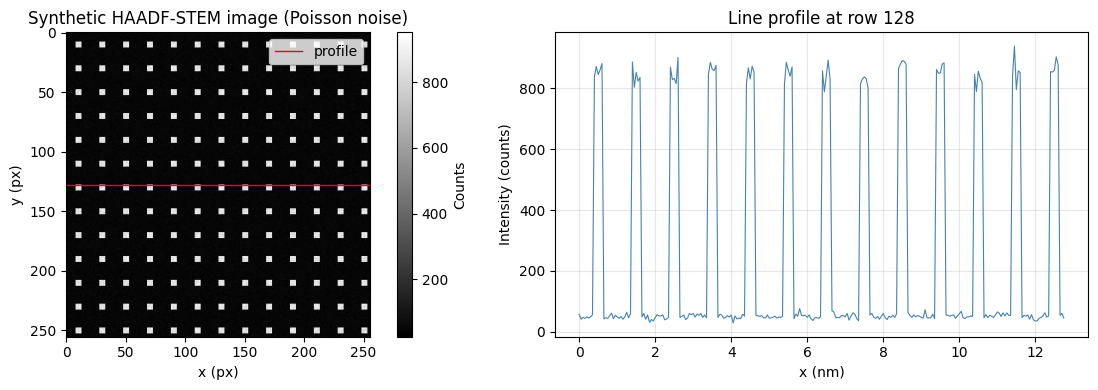

In [11]:
# ── Cell 11: display image + line profile ─────────────────────────────────────
profile_row = N // 2                       # extract from the middle row
profile     = stem_image[profile_row, :]   # 1-D array

pixel_size_nm = 0.05
x_nm = np.arange(N) * pixel_size_nm        # convert pixels → nm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: image
im = axes[0].imshow(stem_image, cmap='gray', origin='upper')
axes[0].axhline(profile_row, color='red', lw=1, label='profile')
axes[0].set_title('Synthetic HAADF-STEM image (Poisson noise)')
axes[0].set_xlabel('x (px)')
axes[0].set_ylabel('y (px)')
plt.colorbar(im, ax=axes[0], label='Counts')
axes[0].legend()

# Right: line profile
axes[1].plot(x_nm, profile, lw=0.8, color='steelblue')
axes[1].set_xlabel('x (nm)')
axes[1].set_ylabel('Intensity (counts)')
axes[1].set_title(f'Line profile at row {profile_row}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 7 — Putting it together: load, inspect, normalise

Real workflow: load file → check shape/dtype → normalise → display.

=== Step 1: inspect ===
  shape : (256, 256)
  dtype : float32
  min   : 25.0
  max   : 952.0
  mean  : 101.6

=== Step 2: normalise ===
  normalised min: 0.0000
  normalised max: 1.0000


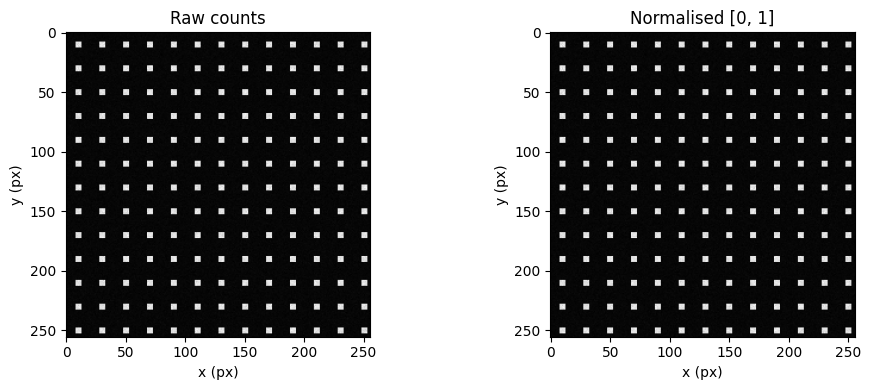

In [12]:
# ── Cell 12: full mini-pipeline ───────────────────────────────────────────────
# In practice you would do: stem_image = tifffile.imread('my_image.tif')
# Here we use the synthetic image already created above.

# Step 1: inspect
print("=== Step 1: inspect ===")
print(f"  shape : {stem_image.shape}")
print(f"  dtype : {stem_image.dtype}")
print(f"  min   : {stem_image.min():.1f}")
print(f"  max   : {stem_image.max():.1f}")
print(f"  mean  : {stem_image.mean():.1f}")

# Step 2: normalise to [0, 1]
print("\n=== Step 2: normalise ===")
norm_image = normalize(stem_image)  # our function from Part 2
print(f"  normalised min: {norm_image.min():.4f}")
print(f"  normalised max: {norm_image.max():.4f}")

# Step 3: display
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(stem_image,  cmap='gray'); axes[0].set_title('Raw counts')
axes[1].imshow(norm_image,  cmap='gray'); axes[1].set_title('Normalised [0, 1]')
for ax in axes:
    ax.set_xlabel('x (px)')
    ax.set_ylabel('y (px)')
plt.tight_layout()
plt.show()

---
## ✏️ YOUR TURN — Final exercise

**Task:** Crop a 64×64-pixel region of interest (ROI) from the centre of `stem_image`,
then min-max-normalise it and display the result alongside the full image.

Fill in each `???`. Run the cell — the assertions at the bottom check your answer.

**Hints (step by step):**

1. The centre coordinates are already given (`cx`, `cy`).
2. Extract a 64×64 ROI using array slicing: `stem_image[cy - half : ???, cx - half : ???]`.
3. Call `normalize(???)` on the ROI.
4. Show both panels with `plt.subplots(1, 2)` and `axes[?].imshow(???, cmap="gray")`.
5. **Bonus:** Draw a red `Rectangle` patch on the full-image panel at position `(cx - half, cy - half)` with width and height `2 * half`.

> *Try to write each `???` yourself before looking at the Solution cell below.*

ROI shape: (64, 64)


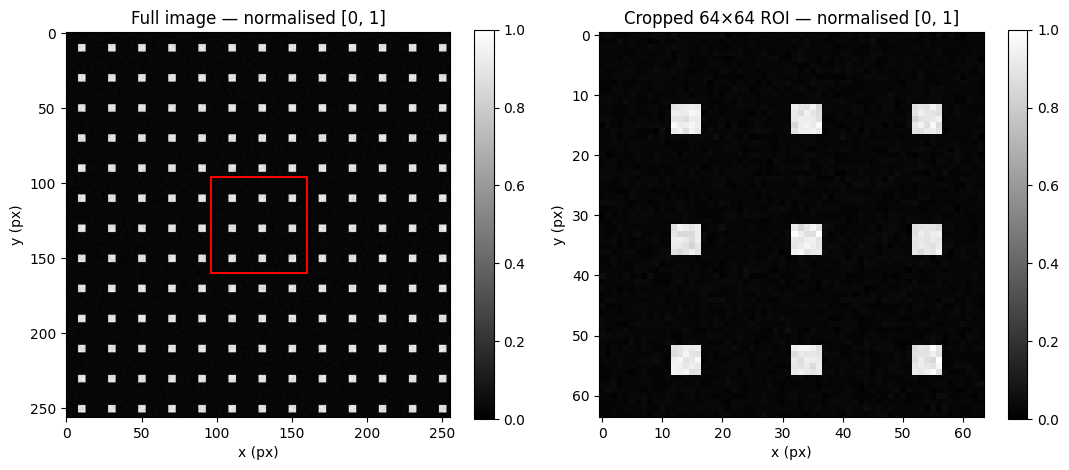


All assertions passed — your ROI crop and normalisation are correct!


In [13]:
# ── Cell 13: YOUR TURN — fill in the blanks ───────────────────────────────────
# The lines marked "(try this yourself)" are where you should write your own code.
# The working version is provided so the notebook executes; cover it up or delete
# it and retype it as practice.

import matplotlib.patches as mpatches

# --- Step 1: centre coordinates (given)
cx = N // 2   # column centre
cy = N // 2   # row centre
half = 32     # ROI half-size in pixels

# --- Step 2: crop ROI   ← (try this yourself)
roi = stem_image[cy - half : cy + half,
                 cx - half : cx + half]
print(f"ROI shape: {roi.shape}")

# --- Step 3: normalise  ← (try this yourself)
norm_full = normalize(stem_image)
norm_roi  = normalize(roi)

# --- Step 4 & 5: display  ← (try this yourself)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = axes[0].imshow(norm_full, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Full image — normalised [0, 1]')
axes[0].set_xlabel('x (px)')
axes[0].set_ylabel('y (px)')
plt.colorbar(im0, ax=axes[0])

# Bonus: draw red rectangle on the full image  ← (try this yourself)
rect = mpatches.Rectangle(
    (cx - half, cy - half), 2 * half, 2 * half,
    linewidth=1.5, edgecolor='red', facecolor='none'
)
axes[0].add_patch(rect)

im1 = axes[1].imshow(norm_roi, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Cropped 64×64 ROI — normalised [0, 1]')
axes[1].set_xlabel('x (px)')
axes[1].set_ylabel('y (px)')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# --- Self-check
assert roi.shape == (64, 64), f"Expected ROI shape (64, 64), got {roi.shape}"
assert abs(norm_roi.min()) < 1e-6,  "Normalised ROI min should be 0"
assert abs(norm_roi.max() - 1) < 1e-6, "Normalised ROI max should be 1"
print("\nAll assertions passed — your ROI crop and normalisation are correct!")


## Solution

Expand this cell after you have made your own attempt.

```python
import matplotlib.patches as mpatches

# Step 1: centre coordinates
cx = N // 2
cy = N // 2
half = 32

# Step 2: crop a 64×64 ROI from the centre
roi = stem_image[cy - half : cy + half,
                 cx - half : cx + half]

# Step 3: normalise both full image and ROI
norm_full = normalize(stem_image)
norm_roi  = normalize(roi)

# Step 4 & 5: display side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im0 = axes[0].imshow(norm_full, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Full image — normalised [0, 1]')
axes[0].set_xlabel('x (px)')
axes[0].set_ylabel('y (px)')
plt.colorbar(im0, ax=axes[0])

# Bonus: red rectangle indicating the ROI
rect = mpatches.Rectangle(
    (cx - half, cy - half), 2 * half, 2 * half,
    linewidth=1.5, edgecolor='red', facecolor='none'
)
axes[0].add_patch(rect)

im1 = axes[1].imshow(norm_roi, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Cropped 64×64 ROI — normalised [0, 1]')
axes[1].set_xlabel('x (px)')
axes[1].set_ylabel('y (px)')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# Self-check
assert roi.shape == (64, 64)
assert abs(norm_roi.min()) < 1e-6
assert abs(norm_roi.max() - 1) < 1e-6
print("All assertions passed!")
```


---
## Summary

| Concept | Key syntax |
|---------|------------|
| Variable assignment | `x = 3.14` |
| List indexing | `lst[0]`, `lst[-1]`, `lst[1:3]` |
| Define function | `def f(x): ... return y` |
| Create array | `np.array([...])`, `np.zeros((m,n))` |
| Shape & dtype | `arr.shape`, `arr.dtype` |
| Index 2-D array | `arr[row, col]` |
| Crop ROI | `arr[r0:r1, c0:c1]` |
| Broadcasting | `arr - arr.mean(axis=1, keepdims=True)` |
| Min-max normalise | `(x - x.min()) / (x.max() - x.min())` |
| Show image | `plt.imshow(arr, cmap='gray')` |

**Next week:** What is learning? Where does detector noise come from? Why does Poisson statistics matter for low-dose EM?

> *Complete this notebook before Week 2. You will use array operations, normalisation, and ROI extraction in every subsequent notebook.*